In [1]:
from QbitSim import *
import torch

In [4]:
max_steps = 12
N_qbits = 3
allowed_gates = "H X Z M CX"
measure_rule = lambda i: i!=0
double_rule = lambda i,j: abs(i-j)==1 and 0 not in [i,j]

env = QbitEnv(N_qbits, allowed_gates, max_steps=max_steps, action_repetition=1, max_cnots=2, starting_aid=False
              measure_rule=measure_rule, double_rule=double_rule)
sarsa = SemiGradSarsa(eps=0.2, alpha=0.1, gamma=1.)
model = ActionModel(max_steps=max_steps, n_actions=env.action_space.n)

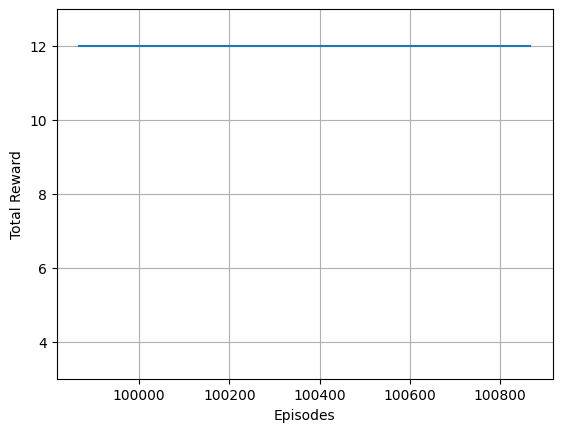

In [8]:
sarsa.setting(eps=0.2, alpha=0.1, gamma=0.9)
info = sarsa.run(env, model, max_episode=100000, max_steps=max_steps, plot_range=[3,max_steps + 1])
wins = [step for step in info if step["win"]]

In [7]:
len(wins)

45

In [9]:
env.test_net(model)

H->[2]
M->[0]	m = 0
X->[1]
CX->[1, 0]
M->[1]	m = 1
M->[2]	m = 0
Z->[0]
Z->[2]
X->[2]
H->[1]
H->[0]
Z->[1]

Failed in 12 steps!
